<div align="center">

![Course](https://img.shields.io/badge/Course-Advanced%20Data%20Science%20Lab-blue?style=for-the-badge&logo=python&logoColor=white)
![Code](https://img.shields.io/badge/Code-MCA33PE21-informational?style=for-the-badge)
![Assignment](https://img.shields.io/badge/Assignment-05-success?style=for-the-badge)

---

# Advanced Data Science Lab [MCA33PE21]
## Practical Assignment - 05
### Supervised Learning — Regression and Classification

---
<br>

| Field | Details |
|---|---|
| **Academic Year** | **2026-2027** |
| **Class / Division** | **SYMCA (Semester-I)** |
| **PRN** |**125M1H064** |
| **Student Name** | **Manthan Vijay Sankpal**|
| **Submission Date** | **16th of September 2026** |
</div>

---

## 1(a) Logistic Regression - Heart Disease

### 1. Import Libraries and Load Dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv("heart_disease_uci.csv")

display(df.head())

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### 2. Explore the Dataset

In [4]:
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (920, 16)

Column Names:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Data Types:
id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object

Missing Values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


### 3. Data Preprocessing

In [5]:
df = df.dropna()

df["sex"] = df["sex"].map({"Male": 0, "Female": 1})

df = pd.get_dummies(
    df,
    columns=["cp", "restecg", "slope", "thal"],
    dtype=int
)

display(df.head())

,id,age,sex,dataset,trestbps,chol,fbs,thalch,exang,oldpeak,...,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,1,63,0,Cleveland,145.0,233.0,True,150.0,False,2.3,...,1,1,0,0,1,0,0,1,0,0
1,2,67,0,Cleveland,160.0,286.0,False,108.0,True,1.5,...,0,1,0,0,0,1,0,0,1,0
2,3,67,0,Cleveland,120.0,229.0,False,129.0,True,2.6,...,0,1,0,0,0,1,0,0,0,1
3,4,37,0,Cleveland,130.0,250.0,False,187.0,False,3.5,...,0,0,1,0,1,0,0,0,1,0
4,5,41,1,Cleveland,130.0,204.0,False,172.0,False,1.4,...,0,1,0,0,0,0,1,0,1,0


### 4. Define Features and Target

In [6]:
X = df.drop(["num", "id", "dataset"], axis=1)
y = df["num"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,cp_asymptomatic,...,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,63,0,145.0,233.0,True,150.0,False,2.3,0.0,0,...,1,1,0,0,1,0,0,1,0,0
1,67,0,160.0,286.0,False,108.0,True,1.5,3.0,1,...,0,1,0,0,0,1,0,0,1,0
2,67,0,120.0,229.0,False,129.0,True,2.6,2.0,1,...,0,1,0,0,0,1,0,0,0,1
3,37,0,130.0,250.0,False,187.0,False,3.5,0.0,0,...,0,0,1,0,1,0,0,0,1,0
4,41,1,130.0,204.0,False,172.0,False,1.4,0.0,0,...,0,1,0,0,0,0,1,0,1,0



Target:


0    0
1    2
2    1
3    0
4    0
Name: num, dtype: int64

### 5. Feature Scaling

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Features scaled successfully.")

Features scaled successfully.


### 6. Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 22)
Testing data: (60, 22)


### 7. Logistic Regression Model

In [9]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


### 8. Make Predictions

In [10]:
y_pred = model.predict(X_test)

print("Predicted Outcomes:")
print(y_pred[:10])

Predicted Outcomes:
[0 0 0 0 0 0 0 0 3 0]


### 9. Model Evaluation

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5833333333333334
Precision: 0.5274324324324324
Recall: 0.5833333333333334
F1-Score: 0.5483835005574136

Confusion Matrix:
[[30  1  0  0  1]
 [ 6  1  3  1  0]
 [ 1  2  1  3  0]
 [ 0  0  2  3  2]
 [ 0  1  0  2  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.94      0.87        32
           1       0.20      0.09      0.12        11
           2       0.17      0.14      0.15         7
           3       0.33      0.43      0.38         7
           4       0.00      0.00      0.00         3

    accuracy                           0.58        60
   macro avg       0.30      0.32      0.30        60
weighted avg       0.53      0.58      0.55        60



## 1(b) Decision Tree - Customer Churn

### 1. Import Libraries and Load Dataset

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2. Explore the Dataset

In [13]:
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing Values:
customerID 

### 3. Data Preprocessing

In [14]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df["SeniorCitizen"] = df["SeniorCitizen"].astype(str)

df = pd.get_dummies(
    df,
    columns=df.select_dtypes(include="object").columns,
    drop_first=True,
    dtype=int
)

display(df.head())

C:\Users\MANTHAN\AppData\Local\Temp\ipykernel_21856\1531031437.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columns=df.select_dtypes(include="object").columns,


,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,1,29.85,29.85,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1,34,56.95,1889.50,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,2,53.85,108.15,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
3,45,42.30,1840.75,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,2,70.70,151.65,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1


### 4. Define Features and Target

In [15]:
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,34,56.95,1889.50,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2,53.85,108.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,45,42.30,1840.75,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,2,70.70,151.65,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0



Target:


0    0
1    0
2    1
3    0
4    1
Name: Churn_Yes, dtype: int64

### 5. Train/Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 7072)
Testing data: (1409, 7072)


### 6. Decision Tree Model

In [17]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


### 7. Make Predictions

In [18]:
y_pred = model.predict(X_test)

print("Predicted Outcomes:")
print(y_pred[:10])

Predicted Outcomes:
[0 1 0 1 0 1 0 0 0 0]


### 8. Model Evaluation

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.772888573456352
Precision: 0.584375
Recall: 0.5
F1-Score: 0.5389048991354467

Confusion Matrix:
[[902 133]
 [187 187]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.58      0.50      0.54       374

    accuracy                           0.77      1409
   macro avg       0.71      0.69      0.69      1409
weighted avg       0.76      0.77      0.77      1409



### 9. Visualize the Decision Tree

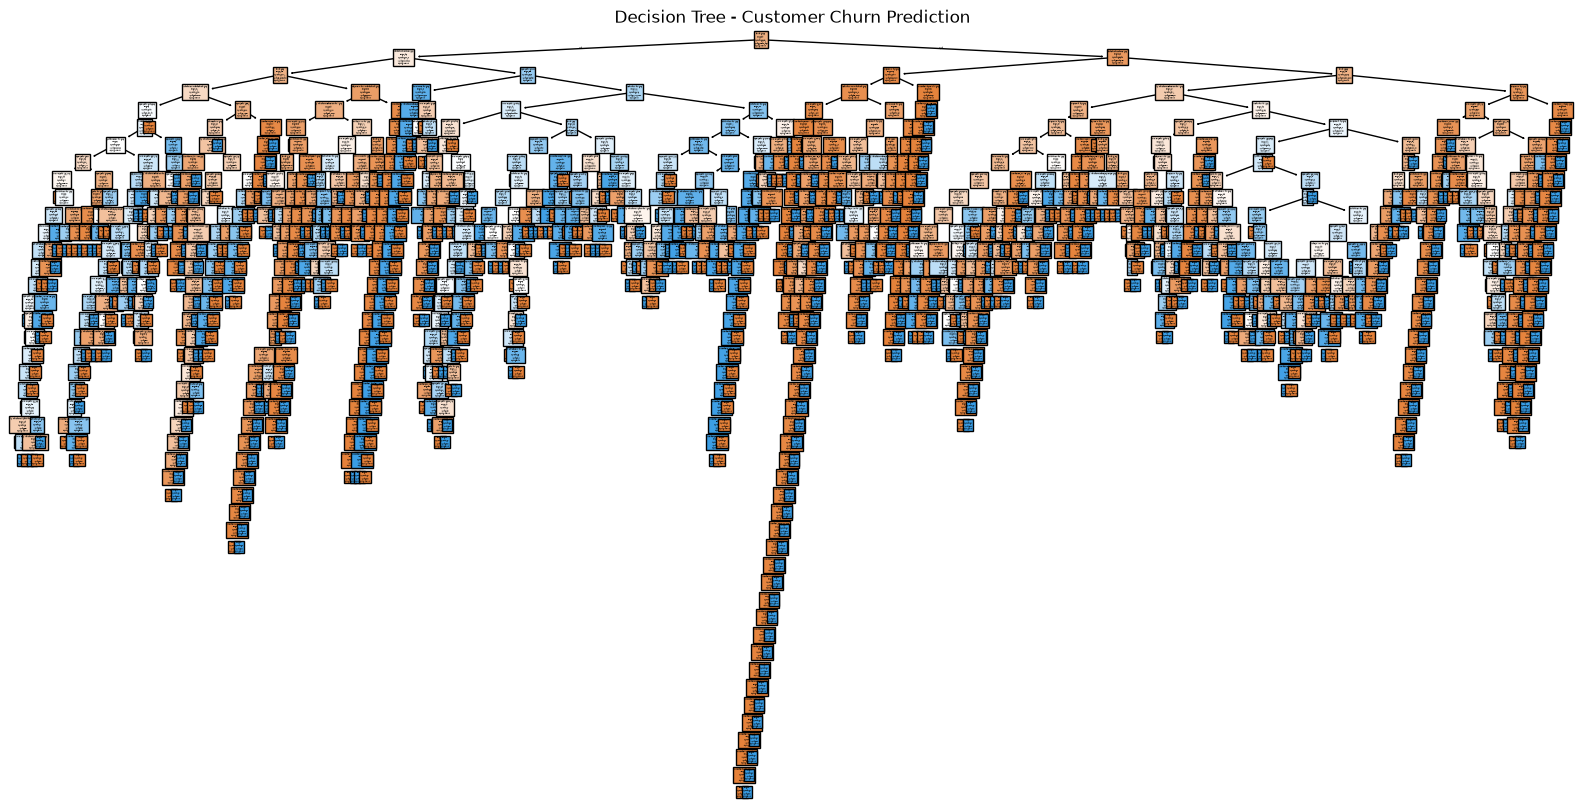

In [20]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Churn", "Churn"],
    filled=True
)

plt.title("Decision Tree - Customer Churn Prediction")
plt.show()

## 1(c) Random Forest - Credit Card Fraud Detection

### 1. Import Libraries and Load Dataset

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv("creditcard.csv")

display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 2. Explore the Dataset

In [22]:
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["Class"].value_counts())

Shape: (284807, 31)

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12 

### 3. Define Features and Target

In [23]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99



Target:


0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

### 4. Train/Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


### 5. Random Forest Model

In [25]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### 6. Make Predictions

In [26]:
y_pred = model.predict(X_test)

print("Predicted Outcomes:")
print(y_pred[:10])

Predicted Outcomes:
[0 0 0 0 0 0 0 0 0 0]


### 7. Model Evaluation

In [27]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9995962220427653
Precision: 0.9411764705882353
Recall: 0.8163265306122449
F1-Score: 0.8743169398907104

Confusion Matrix:
[[56859     5]
 [   18    80]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



## 1(d) SVM - Iris Classification

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### 2. Explore the Dataset

In [29]:
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["target"].value_counts())

Shape: (150, 5)

Column Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Target Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


### 3. Define Features and Target

In [30]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

### 4. Feature Scaling

In [31]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Features scaled successfully.")

Features scaled successfully.


### 5. Train/Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


### 6. SVM Model

In [33]:
model = SVC()

model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


### 7. Make Predictions

In [34]:
y_pred = model.predict(X_test)

print("Predicted Outcomes:")
print(y_pred[:10])

Predicted Outcomes:
[0 2 1 1 0 1 0 0 2 1]


### 8. Model Evaluation

In [35]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667
Precision: 0.9696969696969696
Recall: 0.9666666666666667
F1-Score: 0.9665831244778613

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 2. K-Fold Cross-Validation

### 2(a) Logistic Regression - Heart Disease

### 1. Load and Prepare the Dataset

In [36]:
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv("heart_disease.csv")

print(df.columns.tolist())

['age', 'cholesterol', 'chest_pain_type', 'max_heart_rate', 'heart_disease']


### 3. 5-Fold Stratified Cross-Validation

In [37]:
df["chest_pain_type"] = df["chest_pain_type"].astype("category").cat.codes

X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

display(X.head())

,age,cholesterol,chest_pain_type,max_heart_rate
0,67,286,0,122
1,57,293,2,149
2,43,253,2,100
3,71,164,2,176
4,36,207,1,121


In [38]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for train_index, test_index in skf.split(X, y):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred, average="weighted"))
    recall_scores.append(recall_score(y_test, y_pred, average="weighted"))
    f1_scores.append(f1_score(y_test, y_pred, average="weighted"))

### 5. Fold-wise Accuracy

In [39]:
for i, score in enumerate(accuracy_scores, start=1):
    print(f"Fold {i} Accuracy: {score:.4f}")

Fold 1 Accuracy: 0.7000
Fold 2 Accuracy: 0.6400
Fold 3 Accuracy: 0.6000
Fold 4 Accuracy: 0.6400
Fold 5 Accuracy: 0.6200


### 6. Fold-wise Precision

In [40]:
for i, score in enumerate(precision_scores, start=1):
    print(f"Fold {i} Precision: {score:.4f}")

Fold 1 Precision: 0.7000
Fold 2 Precision: 0.6386
Fold 3 Precision: 0.6000
Fold 4 Precision: 0.6389
Fold 5 Precision: 0.6210


### 7. Fold-wise Recall

In [41]:
for i, score in enumerate(recall_scores, start=1):
    print(f"Fold {i} Recall: {score:.4f}")

Fold 1 Recall: 0.7000
Fold 2 Recall: 0.6400
Fold 3 Recall: 0.6000
Fold 4 Recall: 0.6400
Fold 5 Recall: 0.6200


### 8. Fold-wise F1-Score

In [42]:
for i, score in enumerate(f1_scores, start=1):
    print(f"Fold {i} F1-Score: {score:.4f}")

Fold 1 F1-Score: 0.6974
Fold 2 F1-Score: 0.6382
Fold 3 F1-Score: 0.6000
Fold 4 F1-Score: 0.6353
Fold 5 F1-Score: 0.6077


### 9. Average Performance

In [43]:
print("Average Accuracy:", sum(accuracy_scores) / len(accuracy_scores))
print("Average Precision:", sum(precision_scores) / len(precision_scores))
print("Average Recall:", sum(recall_scores) / len(recall_scores))
print("Average F1-Score:", sum(f1_scores) / len(f1_scores))

Average Accuracy: 0.64
Average Precision: 0.6396995665077108
Average Recall: 0.64
Average F1-Score: 0.6357296048712681


### Q2(b) Decision Tree - Telco Customer Churn
### 1. Load Dataset`

In [44]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2. Preprocessing the Dataset

In [45]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df = df.drop("customerID", axis=1)

df = pd.get_dummies(
    df,
    columns=df.select_dtypes(include="object").columns,
    drop_first=True,
    dtype=int
)

display(df.head())

C:\Users\MANTHAN\AppData\Local\Temp\ipykernel_21856\2698408123.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columns=df.select_dtypes(include="object").columns,


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


### 3. Prepare Features and Target

In [46]:
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

display(X.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


### 4. 5-Fold Stratified Cross-Validation

In [47]:
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

### 5. Train Decision Tree and Calculate Fold-wise Metrics

In [48]:
for train_index, test_index in skf.split(X, y):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

### 6. Fold-wise Performance

In [49]:
for i in range(5):
    print(f"Fold {i + 1}")
    print("Accuracy:", accuracy_scores[i])
    print("Precision:", precision_scores[i])
    print("Recall:", recall_scores[i])
    print("F1-Score:", f1_scores[i])
    print()

Fold 1
Accuracy: 0.7125621007806955
Precision: 0.45866666666666667
Recall: 0.45989304812834225
F1-Score: 0.45927903871829107

Fold 2
Accuracy: 0.7189496096522356
Precision: 0.47277227722772275
Recall: 0.5106951871657754
F1-Score: 0.4910025706940874

Fold 3
Accuracy: 0.7423704755145494
Precision: 0.5148247978436657
Recall: 0.5106951871657754
F1-Score: 0.512751677852349

Fold 4
Accuracy: 0.7251420454545454
Precision: 0.4810810810810811
Recall: 0.4772117962466488
F1-Score: 0.4791386271870794

Fold 5
Accuracy: 0.7336647727272727
Precision: 0.49869451697127937
Recall: 0.5106951871657754
F1-Score: 0.5046235138705416



### 7. Average Performance

In [50]:
print("Average Accuracy:", sum(accuracy_scores) / len(accuracy_scores))
print("Average Precision:", sum(precision_scores) / len(precision_scores))
print("Average Recall:", sum(recall_scores) / len(recall_scores))
print("Average F1-Score:", sum(f1_scores) / len(f1_scores))

Average Accuracy: 0.7265378008258597
Average Precision: 0.4852078679580831
Average Recall: 0.4938380811744635
Average F1-Score: 0.48935908566446973


### Q2(c) Random Forest - Credit Card Fraud Detection
### 1. Load Dataset

In [51]:
df = pd.read_csv("creditcard.csv")

display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 2. Prepare Features and Target

In [52]:
X = df.drop("Class", axis=1)
y = df["Class"]

display(X.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


### 3. 5-Fold Stratified Cross-Validation

In [53]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

### 4. Train Random Forest and Calculate Fold-wise Metrics

In [54]:
for train_index, test_index in skf.split(X, y):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

### 5. Fold-wise Performance

In [55]:
for i in range(5):
    print(f"Fold {i + 1}")
    print("Accuracy:", accuracy_scores[i])
    print("Precision:", precision_scores[i])
    print("Recall:", recall_scores[i])
    print("F1-Score:", f1_scores[i])
    print()

Fold 1
Accuracy: 0.9994733330992591
Precision: 0.9156626506024096
Recall: 0.7676767676767676
F1-Score: 0.8351648351648352

Fold 2
Accuracy: 0.9995962220427653
Precision: 0.975
Recall: 0.7878787878787878
F1-Score: 0.8715083798882681

Fold 3
Accuracy: 0.9996313266972139
Precision: 0.963855421686747
Recall: 0.8163265306122449
F1-Score: 0.8839779005524862

Fold 4
Accuracy: 0.9995611032109689
Precision: 0.9620253164556962
Recall: 0.7755102040816326
F1-Score: 0.8587570621468926

Fold 5
Accuracy: 0.9995084355962852
Precision: 0.926829268292683
Recall: 0.7755102040816326
F1-Score: 0.8444444444444444



### 6. Average Performance

In [56]:
print("Average Accuracy:", sum(accuracy_scores) / len(accuracy_scores))
print("Average Precision:", sum(precision_scores) / len(precision_scores))
print("Average Recall:", sum(recall_scores) / len(recall_scores))
print("Average F1-Score:", sum(f1_scores) / len(f1_scores))

Average Accuracy: 0.9995540841292986
Average Precision: 0.9486745314075071
Average Recall: 0.7845804988662131
Average F1-Score: 0.8587705244393853


### Q2(d) SVM - Iris Dataset
### 1. Load Dataset

In [57]:
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### 2. Prepare Features and Target

In [58]:
X = df.drop("target", axis=1)
y = df["target"]

display(X.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 3. 5-Fold Stratified Cross-Validation

In [59]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

### 4. Train SVM and Calculate Fold-wise Metrics

In [60]:
for train_index, test_index in skf.split(X, y):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = SVC()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(
        precision_score(y_test, y_pred, average="weighted")
    )
    recall_scores.append(
        recall_score(y_test, y_pred, average="weighted")
    )
    f1_scores.append(
        f1_score(y_test, y_pred, average="weighted")
    )

### 5. Fold-wise Performance

In [61]:
for i in range(5):
    print(f"Fold {i + 1}")
    print("Accuracy:", accuracy_scores[i])
    print("Precision:", precision_scores[i])
    print("Recall:", recall_scores[i])
    print("F1-Score:", f1_scores[i])
    print()

Fold 1
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0

Fold 2
Accuracy: 0.9666666666666667
Precision: 0.9696969696969696
Recall: 0.9666666666666667
F1-Score: 0.9665831244778613

Fold 3
Accuracy: 0.9
Precision: 0.9023569023569025
Recall: 0.9
F1-Score: 0.8997493734335839

Fold 4
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0

Fold 5
Accuracy: 0.9333333333333333
Precision: 0.9333333333333333
Recall: 0.9333333333333333
F1-Score: 0.9333333333333333



### 6. Average Performance

In [62]:
print("Average Accuracy:", sum(accuracy_scores) / len(accuracy_scores))
print("Average Precision:", sum(precision_scores) / len(precision_scores))
print("Average Recall:", sum(recall_scores) / len(recall_scores))
print("Average F1-Score:", sum(f1_scores) / len(f1_scores))

Average Accuracy: 0.96
Average Precision: 0.9610774410774411
Average Recall: 0.96
Average F1-Score: 0.9599331662489557


---

<div align="center">

### Declaration

_I hereby declare that the work submitted in this practical assignment is my own and has not been copied from any other source._

| | |
|---|---|
| **Student Name** | **Manthan Sankpal**|
| **PRN** | **125M1H064**|
| **Date** | **16th September 2026**|

---

**Prof. Prakash Ukhalkar**  
Course Teacher - Advanced Data Science Lab [MCA33PE21]

![](https://img.shields.io/badge/MCA33PE21-Advanced%20Data%20Science%20Lab-blue?style=flat-square)
![](https://img.shields.io/badge/Practical%20Assignment-05-green?style=flat-square)

</div>